# **Validation Experiment Analysis**

This notebook consolidates the corrected validation-only experiments for the Nexar dashcam collision prediction project.

It is designed to support later article writing by keeping the training commands, evaluation artifacts, tables, threshold sweeps, and risk curves in one reproducible place.

## **Experiments**

- `temporal_alert_224_split`: ResNet18 trained from scratch using the fixed video split.
- `temporal_alert_224_pretrained`: ResNet18 initialized with ImageNet weights using the same fixed split.

Validation protocol:

- Split file: `data/interim/sample_100_videos_splits.csv`
- Evaluation split: `val`
- Validation videos: 20 total, 10 positive and 10 negative
- Temporal scoring: 1 FPS
- Default alert threshold: 0.50

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

REPORTS_DIR = PROJECT_ROOT / 'models' / 'reports'
PREDICTIONS_DIR = PROJECT_ROOT / 'outputs' / 'predictions'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
SPLIT_CSV = PROJECT_ROOT / 'data' / 'interim' / 'sample_100_videos_splits.csv'

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

PROJECT_ROOT

WindowsPath('c:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction')

## **Optional: run the full experiment pipeline**

The cells below can rerun the split creation, training, temporal evaluation, and threshold sweep.

By default, `RUN_TRAINING = False` because training and video scoring can take time. Change it to `True` only when you want to regenerate the artifacts.

In [2]:
RUN_TRAINING = False

python_exe = PROJECT_ROOT / 'venv' / 'Scripts' / 'python.exe'
if not python_exe.exists():
    python_exe = Path(sys.executable)

commands = [
    [
        str(python_exe), 'scripts/create_video_split.py',
        '--input', 'data/interim/sample_100_videos.csv',
        '--output', 'data/interim/sample_100_videos_splits.csv',
        '--val-size', '0.2',
        '--random-state', '42',
    ],
    [
        str(python_exe), 'scripts/train_baseline.py',
        '--manifest', 'data/interim/temporal_frames_224_manifest.csv',
        '--split-manifest', 'data/interim/sample_100_videos_splits.csv',
        '--experiment-name', 'temporal_alert_224_split',
        '--epochs', '3',
        '--batch-size', '64',
        '--learning-rate', '0.0001',
        '--num-workers', '2',
    ],
    [
        str(python_exe), 'scripts/evaluate_model.py',
        '--checkpoint', 'models/checkpoints/temporal_alert_224_split_resnet18.pt',
        '--experiment-name', 'temporal_alert_224_split',
        '--sample-csv', 'data/interim/sample_100_videos_splits.csv',
        '--split', 'val',
        '--fps', '1',
        '--threshold', '0.5',
        '--batch-size', '32',
    ],
    [
        str(python_exe), 'scripts/sweep_alert_thresholds.py',
        '--experiment-name', 'temporal_alert_224_split',
        '--sample-csv', 'data/interim/sample_100_videos_splits.csv',
        '--split', 'val',
    ],
    [
        str(python_exe), 'scripts/train_baseline.py',
        '--manifest', 'data/interim/temporal_frames_224_manifest.csv',
        '--split-manifest', 'data/interim/sample_100_videos_splits.csv',
        '--experiment-name', 'temporal_alert_224_pretrained',
        '--pretrained',
        '--epochs', '8',
        '--batch-size', '64',
        '--learning-rate', '0.00005',
        '--num-workers', '2',
    ],
    [
        str(python_exe), 'scripts/evaluate_model.py',
        '--checkpoint', 'models/checkpoints/temporal_alert_224_pretrained_resnet18.pt',
        '--experiment-name', 'temporal_alert_224_pretrained',
        '--sample-csv', 'data/interim/sample_100_videos_splits.csv',
        '--split', 'val',
        '--fps', '1',
        '--threshold', '0.5',
        '--batch-size', '32',
    ],
    [
        str(python_exe), 'scripts/sweep_alert_thresholds.py',
        '--experiment-name', 'temporal_alert_224_pretrained',
        '--sample-csv', 'data/interim/sample_100_videos_splits.csv',
        '--split', 'val',
    ],
]

def run_command(command: list[str]) -> None:
    print(' '.join(command))
    completed = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    print(completed.stdout)
    if completed.returncode != 0:
        raise RuntimeError(f'Command failed with exit code {completed.returncode}')

if RUN_TRAINING:
    for command in commands:
        run_command(command)
else:
    print('RUN_TRAINING is False. Existing artifacts will be loaded from disk.')

RUN_TRAINING is False. Existing artifacts will be loaded from disk.


## **Load experiment artifacts**

In [3]:
experiments = {
    'Scratch': 'temporal_alert_224_split',
    'Pretrained': 'temporal_alert_224_pretrained',
}

def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f'Missing artifact: {path}')
    return json.loads(path.read_text(encoding='utf-8'))

training_reports = {
    label: load_json(REPORTS_DIR / f'{name}_metrics.json')
    for label, name in experiments.items()
}
alert_reports = {
    label: load_json(REPORTS_DIR / f'{name}_alert_metrics.json')
    for label, name in experiments.items()
}
sweeps = {
    label: pd.read_csv(REPORTS_DIR / f'{name}_alert_threshold_sweep.csv')
    for label, name in experiments.items()
}

print('Loaded experiments:', ', '.join(experiments.keys()))

Loaded experiments: Scratch, Pretrained


## **Split summary**

In [4]:
split_df = pd.read_csv(SPLIT_CSV, dtype={'id': str})
split_summary = (
    split_df[['id', 'target', 'split']]
    .drop_duplicates('id')
    .groupby(['split', 'target'])
    .size()
    .rename('videos')
    .reset_index()
)
split_summary

,split,target,videos
0,train,0,40
1,train,1,40
2,val,0,10
3,val,1,10


## **Frame-level validation metrics**

In [5]:
frame_rows = []
for label, report in training_reports.items():
    row = {
        'model': label,
        'experiment': experiments[label],
        'pretrained': report['config'].get('pretrained'),
        'epochs': int(report['config'].get('epochs')),
        'train_frames': report['train_frames'],
        'val_frames': report['val_frames'],
        **report['frame_metrics'],
    }
    frame_rows.append(row)

frame_metrics_df = pd.DataFrame(frame_rows)
frame_metrics_df

,model,experiment,pretrained,epochs,train_frames,val_frames,accuracy,precision,recall,f1,roc_auc
0,Scratch,temporal_alert_224_split,False,3,6209,1551,0.791747,0.083019,0.215686,0.119891,0.501042
1,Pretrained,temporal_alert_224_pretrained,True,8,6209,1551,0.907801,0.081633,0.039216,0.052980,0.564859


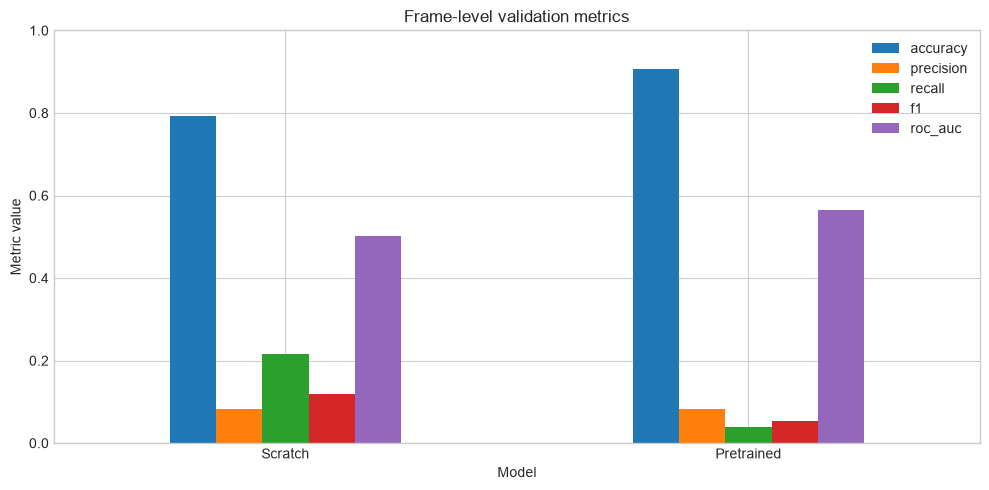

In [6]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
plot_df = frame_metrics_df.set_index('model')[metric_cols]
ax = plot_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
ax.set_title('Frame-level validation metrics')
ax.set_ylabel('Metric value')
ax.set_xlabel('Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Training history curves**

In [7]:
history_frames = []
for label, report in training_reports.items():
    history_df = pd.DataFrame(report['history'])
    history_df['model'] = label
    history_frames.append(history_df)

history_all = pd.concat(history_frames, ignore_index=True)
history_all

,epoch,train_loss,accuracy,precision,recall,f1,roc_auc,model
0,1,0.639669,0.852998,0.036765,0.049020,0.042017,0.477490,Scratch
1,2,0.543833,0.589297,0.077409,0.480392,0.133333,0.515809,Scratch
2,3,0.422289,0.791747,0.083019,0.215686,0.119891,0.501042,Scratch
3,1,0.532278,0.826564,0.067358,0.127451,0.088136,0.559588,Pretrained
4,2,0.208283,0.858156,0.078571,0.107843,0.090909,0.604440,Pretrained
5,3,0.100449,0.898130,0.062500,0.039216,0.048193,0.599771,Pretrained
6,4,0.104487,0.906512,0.042553,0.019608,0.026846,0.583892,Pretrained
7,5,0.055273,0.908446,0.045455,0.019608,0.027397,0.567802,Pretrained
8,6,0.032093,0.907801,0.127273,0.068627,0.089172,0.562322,Pretrained
9,7,0.017997,0.927144,0.133333,0.019608,0.034188,0.588073,Pretrained


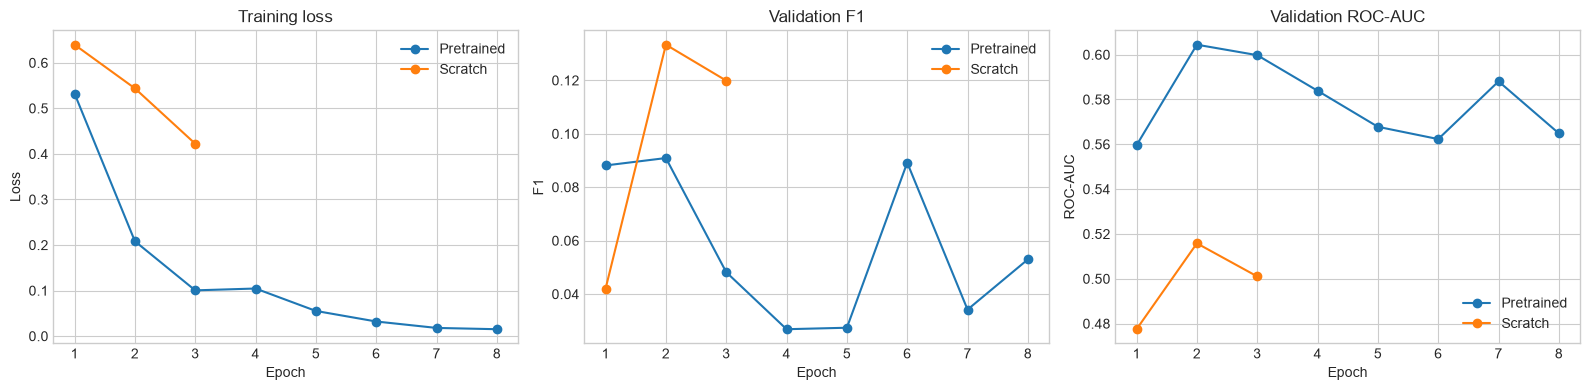

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for label, history_df in history_all.groupby('model'):
    axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label=label)
    axes[1].plot(history_df['epoch'], history_df['f1'], marker='o', label=label)
    axes[2].plot(history_df['epoch'], history_df['roc_auc'], marker='o', label=label)

axes[0].set_title('Training loss')
axes[1].set_title('Validation F1')
axes[2].set_title('Validation ROC-AUC')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend()
axes[0].set_ylabel('Loss')
axes[1].set_ylabel('F1')
axes[2].set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

## **Temporal alert metrics at threshold 0.50**

In [9]:
alert_rows = []
for label, report in alert_reports.items():
    row = {
        'model': label,
        'experiment': experiments[label],
        'threshold': float(report['config']['threshold']),
        **report['metrics'],
    }
    alert_rows.append(row)

alert_metrics_df = pd.DataFrame(alert_rows)
display_cols = [
    'model', 'threshold', 'predicted_alerts', 'true_positive_alerts',
    'false_positive_alerts', 'missed_events', 'alert_precision', 'alert_recall',
    'false_alarm_rate', 'missed_event_rate', 'mean_predicted_lead_time',
    'mean_alert_time_error',
]
alert_metrics_df[display_cols]

,model,threshold,predicted_alerts,true_positive_alerts,false_positive_alerts,missed_events,alert_precision,alert_recall,false_alarm_rate,missed_event_rate,mean_predicted_lead_time,mean_alert_time_error
0,Scratch,0.5,10,4,5,6,0.444444,0.4,0.5,0.6,19.952500,-17.959500
1,Pretrained,0.5,8,3,3,7,0.500000,0.3,0.3,0.7,12.010667,-9.774333


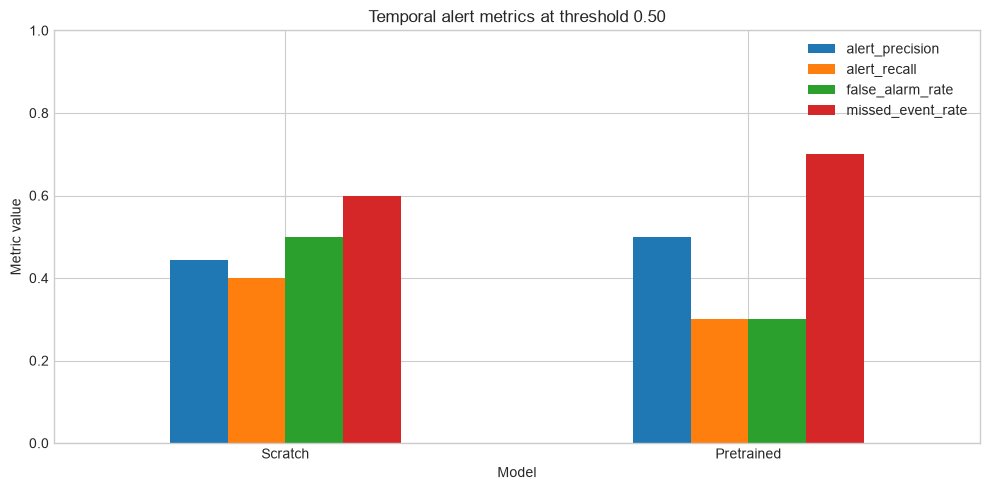

In [10]:
alert_plot_cols = ['alert_precision', 'alert_recall', 'false_alarm_rate', 'missed_event_rate']
ax = alert_metrics_df.set_index('model')[alert_plot_cols].plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
ax.set_title('Temporal alert metrics at threshold 0.50')
ax.set_ylabel('Metric value')
ax.set_xlabel('Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Threshold sweep curves**

The threshold sweep is more useful than a single threshold because collision alerts always involve a trade-off between recall and false alarms.

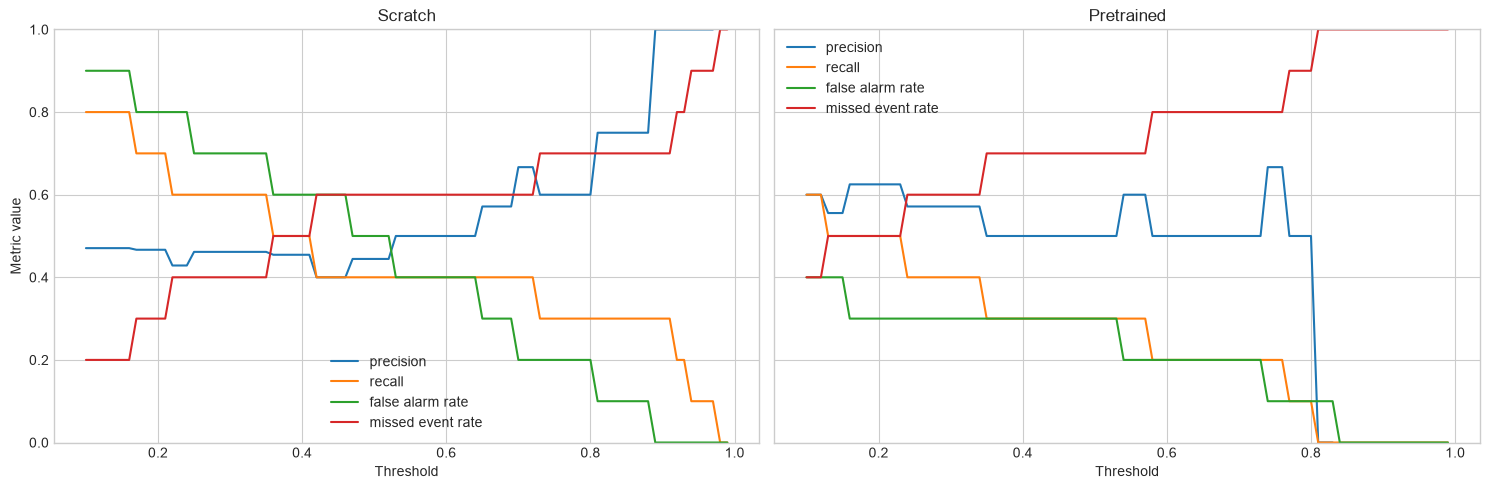

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, (label, sweep_df) in zip(axes, sweeps.items()):
    ax.plot(sweep_df['threshold'], sweep_df['alert_precision'], label='precision')
    ax.plot(sweep_df['threshold'], sweep_df['alert_recall'], label='recall')
    ax.plot(sweep_df['threshold'], sweep_df['false_alarm_rate'], label='false alarm rate')
    ax.plot(sweep_df['threshold'], sweep_df['missed_event_rate'], label='missed event rate')
    ax.set_title(label)
    ax.set_xlabel('Threshold')
    ax.set_ylim(0, 1)
    ax.legend()

axes[0].set_ylabel('Metric value')
plt.tight_layout()
plt.show()

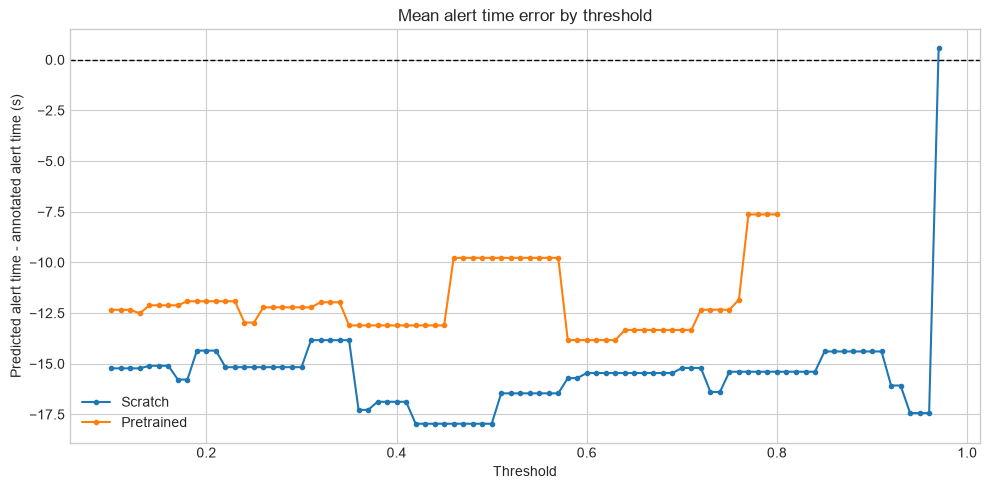

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, sweep_df in sweeps.items():
    ax.plot(sweep_df['threshold'], sweep_df['mean_alert_time_error'], marker='o', markersize=3, label=label)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Mean alert time error by threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Predicted alert time - annotated alert time (s)')
ax.legend()
plt.tight_layout()
plt.show()

## Operating point selection

A threshold with zero false alarms but zero recall is not useful. The table below first applies a minimum recall constraint, then chooses the threshold with the lowest false alarm rate.

In [13]:
def choose_operating_point(sweep_df: pd.DataFrame, min_recall: float) -> pd.Series | None:
    candidates = sweep_df[sweep_df['alert_recall'] >= min_recall].copy()
    if candidates.empty:
        return None
    candidates = candidates.sort_values(
        ['false_alarm_rate', 'missed_event_rate', 'alert_precision', 'mean_alert_time_error'],
        ascending=[True, True, False, False],
    )
    return candidates.iloc[0]

rows = []
for min_recall in [0.7, 0.6, 0.5, 0.4, 0.3]:
    for label, sweep_df in sweeps.items():
        point = choose_operating_point(sweep_df, min_recall)
        if point is None:
            rows.append({'model': label, 'min_recall': min_recall, 'threshold': np.nan})
            continue
        rows.append({
            'model': label,
            'min_recall': min_recall,
            'threshold': point['threshold'],
            'precision': point['alert_precision'],
            'recall': point['alert_recall'],
            'false_alarm_rate': point['false_alarm_rate'],
            'missed_event_rate': point['missed_event_rate'],
            'mean_lead_time': point['mean_predicted_lead_time'],
            'mean_alert_error': point['mean_alert_time_error'],
        })

operating_points_df = pd.DataFrame(rows)
operating_points_df

,model,min_recall,threshold,precision,recall,false_alarm_rate,missed_event_rate,mean_lead_time,mean_alert_error
0,Scratch,0.7,0.19,0.466667,0.7,0.8,0.3,16.267429,-14.351714
1,Pretrained,0.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Scratch,0.6,0.31,0.461538,0.6,0.7,0.4,15.907500,-13.835833
3,Pretrained,0.6,0.10,0.600000,0.6,0.4,0.4,14.117500,-12.338167
4,Scratch,0.5,0.38,0.454545,0.5,0.6,0.5,18.682400,-16.876400
5,Pretrained,0.5,0.18,0.625000,0.5,0.3,0.5,13.855600,-11.916400
6,Scratch,0.4,0.70,0.666667,0.4,0.2,0.6,17.202500,-15.209500
7,Pretrained,0.4,0.18,0.625000,0.5,0.3,0.5,13.855600,-11.916400
8,Scratch,0.3,0.89,1.000000,0.3,0.0,0.7,16.126000,-14.393667
9,Pretrained,0.3,0.54,0.600000,0.3,0.2,0.7,12.010667,-9.774333


Recommended current operating point:

- Model: `temporal_alert_224_pretrained`
- Threshold: `0.18`
- Reason: it keeps recall at `0.50`, improves precision, reduces false alarms, and makes alert timing less extreme compared with the scratch model at matched recall.

In [14]:
recommended = sweeps['Pretrained'].loc[np.isclose(sweeps['Pretrained']['threshold'], 0.18)]
recommended[[
    'threshold', 'alert_precision', 'alert_recall', 'false_alarm_rate',
    'missed_event_rate', 'mean_predicted_lead_time', 'mean_alert_time_error',
]]

,threshold,alert_precision,alert_recall,false_alarm_rate,missed_event_rate,mean_predicted_lead_time,mean_alert_time_error
8,0.18,0.625,0.5,0.3,0.5,13.8556,-11.9164


## Risk curves by video

The next cells plot risk score over time for selected validation videos. Vertical lines are shown for `time_of_alert` and `time_of_event` when the video is positive.

In [15]:
risk_scores = {
    label: pd.read_csv(PREDICTIONS_DIR / f'{name}_temporal_risk_scores.csv', dtype={'id': str})
    for label, name in experiments.items()
}

val_videos = split_df[split_df['split'] == 'val'].copy()
positive_ids = val_videos[val_videos['target'] == 1]['id'].head(3).tolist()
negative_ids = val_videos[val_videos['target'] == 0]['id'].head(3).tolist()
selected_video_ids = positive_ids + negative_ids
selected_video_ids

['00364', '00640', '00783', '01801', '02034', '01815']

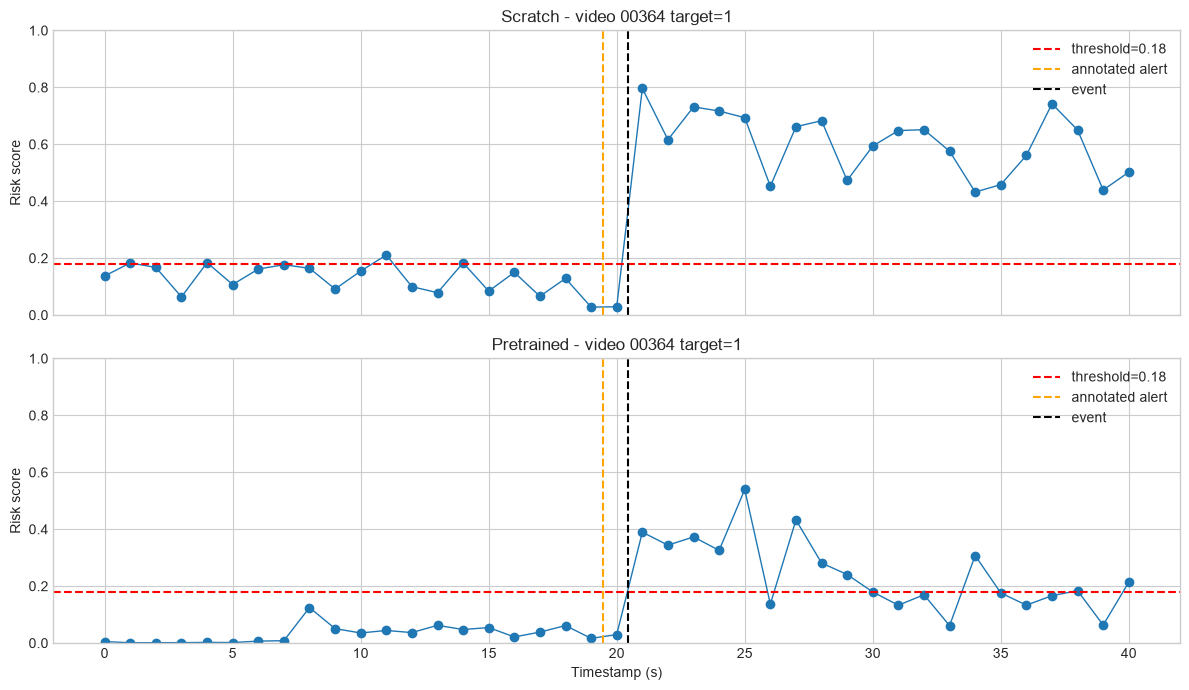

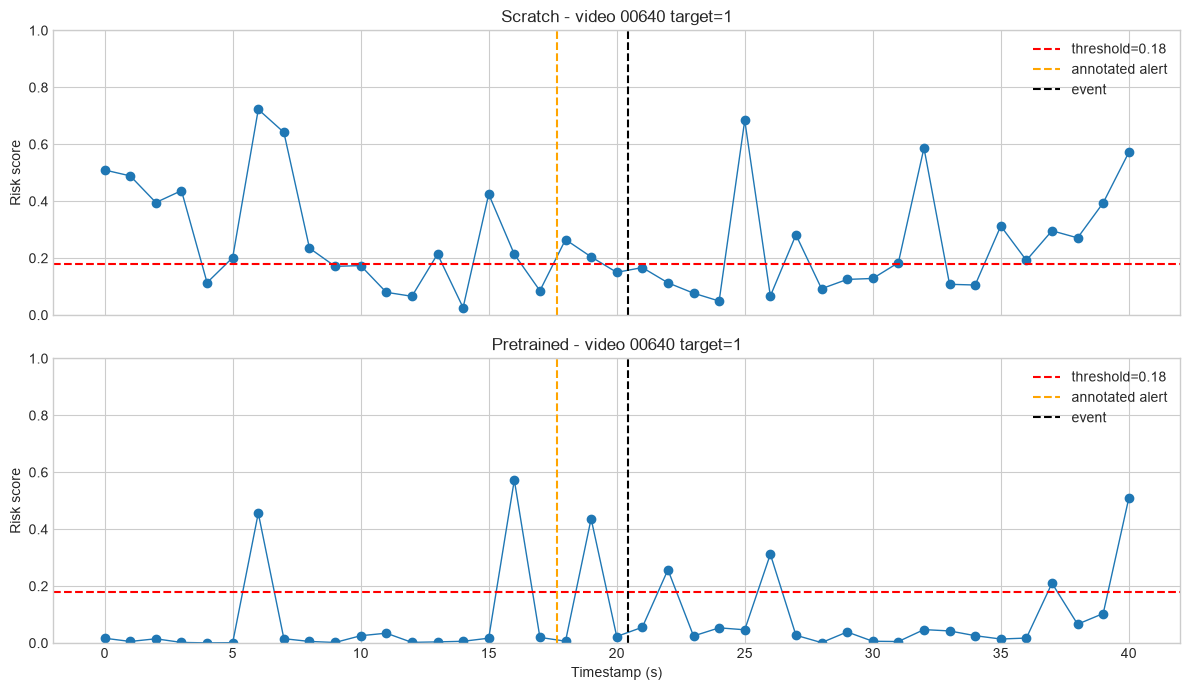

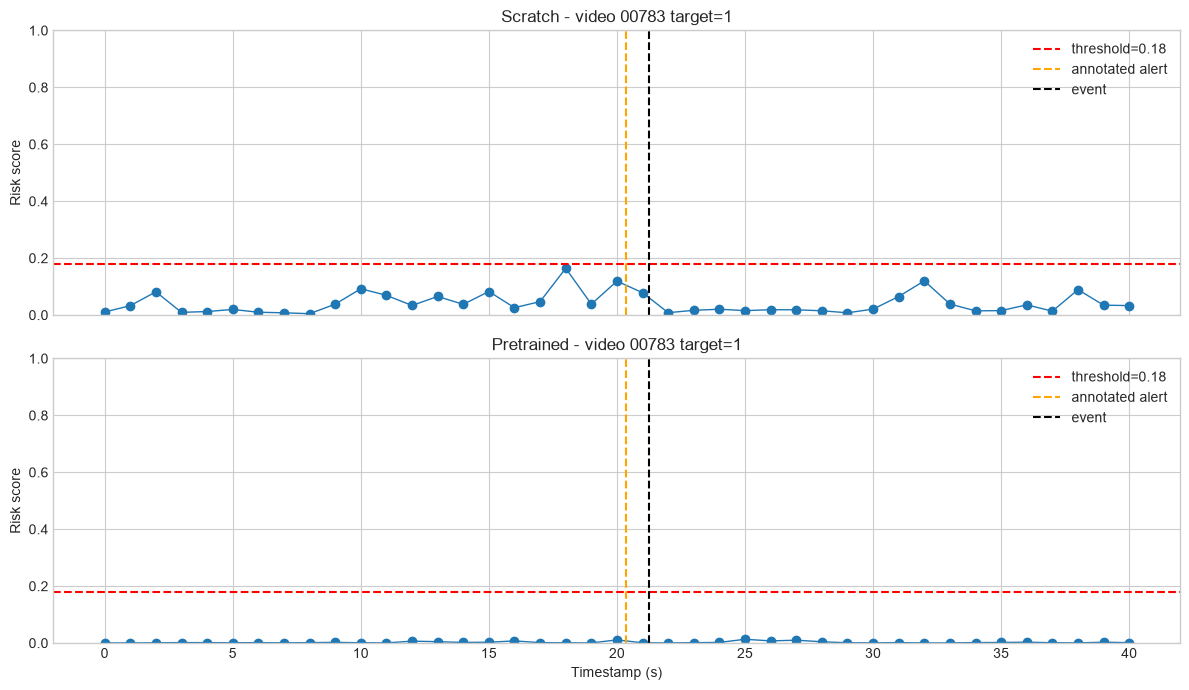

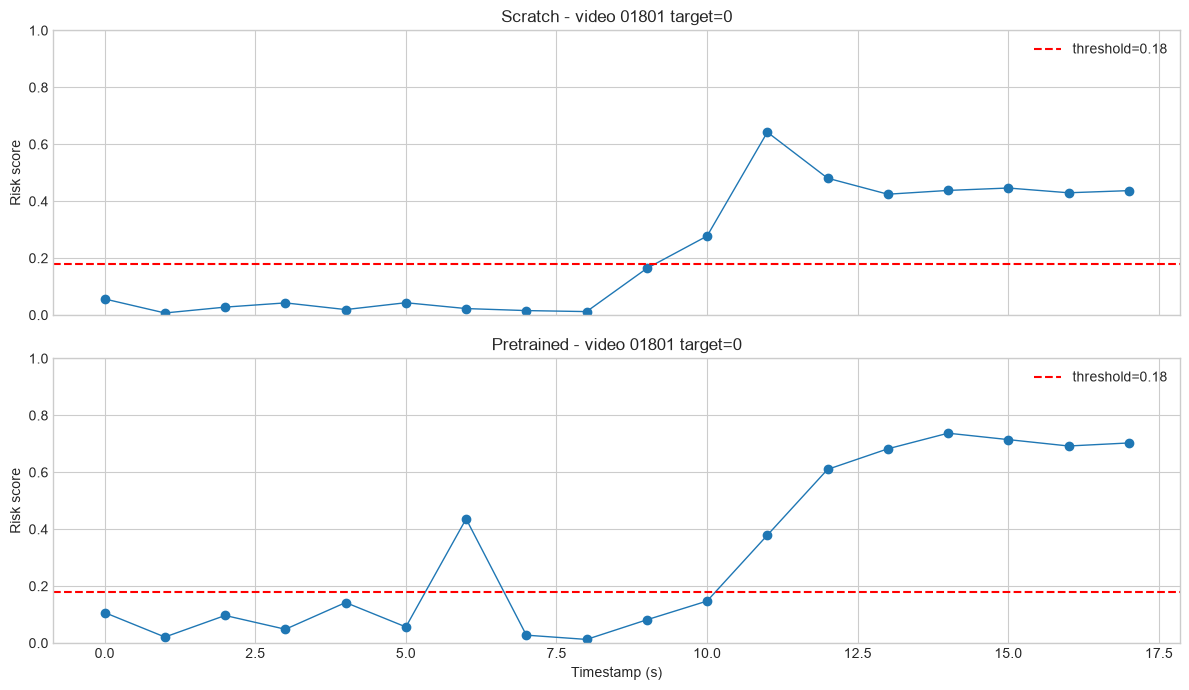

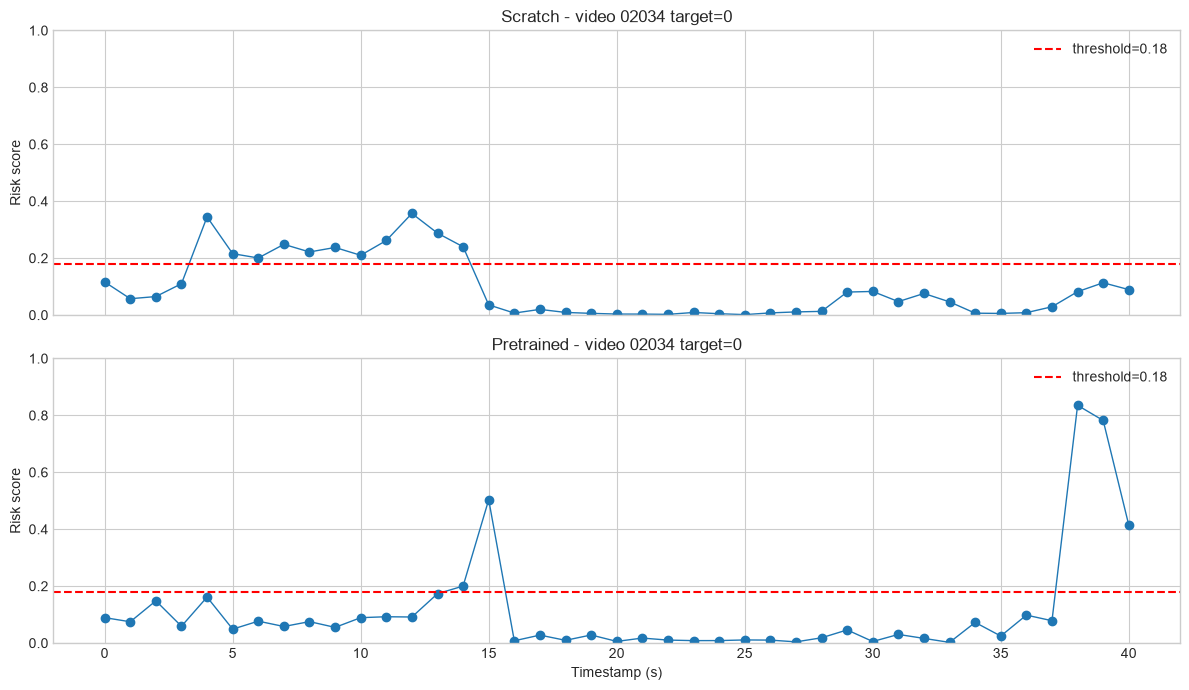

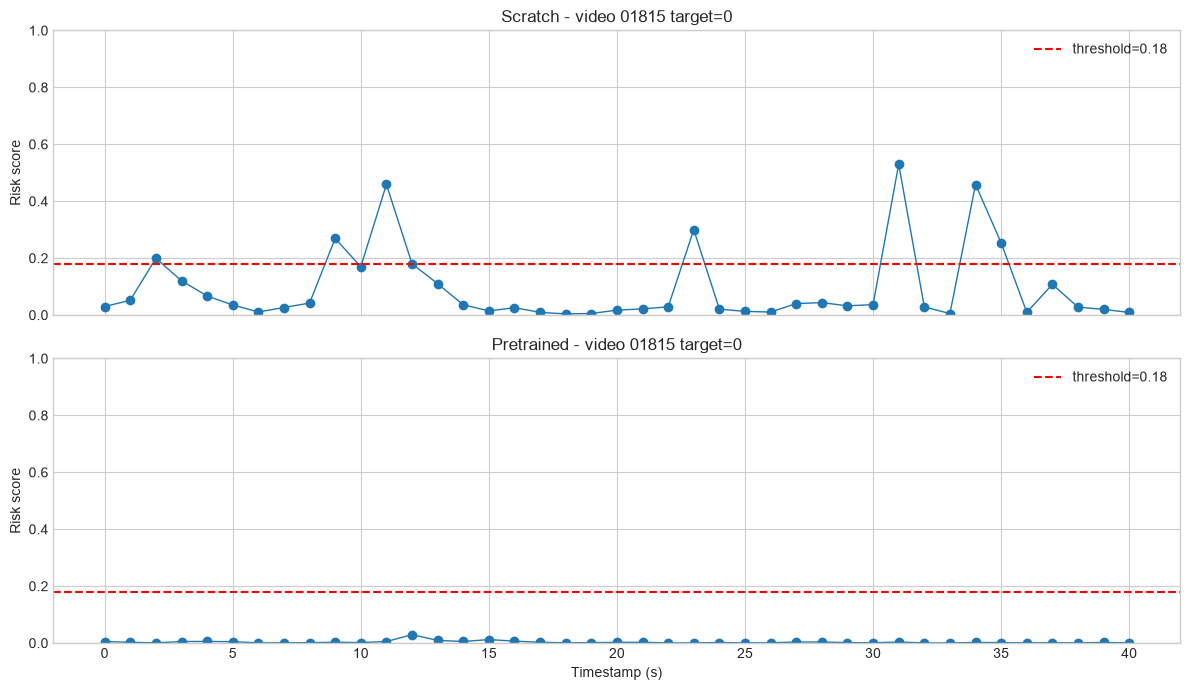

In [16]:
def plot_risk_curve(video_id: str, threshold: float = 0.18) -> None:
    row = val_videos[val_videos['id'] == video_id].iloc[0]
    fig, axes = plt.subplots(len(risk_scores), 1, figsize=(12, 3.5 * len(risk_scores)), sharex=True)
    if len(risk_scores) == 1:
        axes = [axes]

    for ax, (label, scores_df) in zip(axes, risk_scores.items()):
        video_scores = scores_df[scores_df['id'] == video_id]
        ax.plot(video_scores['timestamp'], video_scores['risk_score'], marker='o', linewidth=1)
        ax.axhline(threshold, color='red', linestyle='--', label=f'threshold={threshold}')
        if int(row['target']) == 1:
            ax.axvline(float(row['time_of_alert']), color='orange', linestyle='--', label='annotated alert')
            ax.axvline(float(row['time_of_event']), color='black', linestyle='--', label='event')
        ax.set_title(f'{label} - video {video_id} target={int(row["target"])}')
        ax.set_ylabel('Risk score')
        ax.set_ylim(0, 1)
        ax.legend(loc='best')

    axes[-1].set_xlabel('Timestamp (s)')
    plt.tight_layout()
    plt.show()

for video_id in selected_video_ids:
    plot_risk_curve(video_id, threshold=0.18)

## Saved diagnostic figures

If the training scripts generated confusion matrices, ROC curves, and threshold sweep figures, this cell displays them directly in the notebook.

outputs\figures\temporal_alert_224_split_frame_confusion_matrix.png


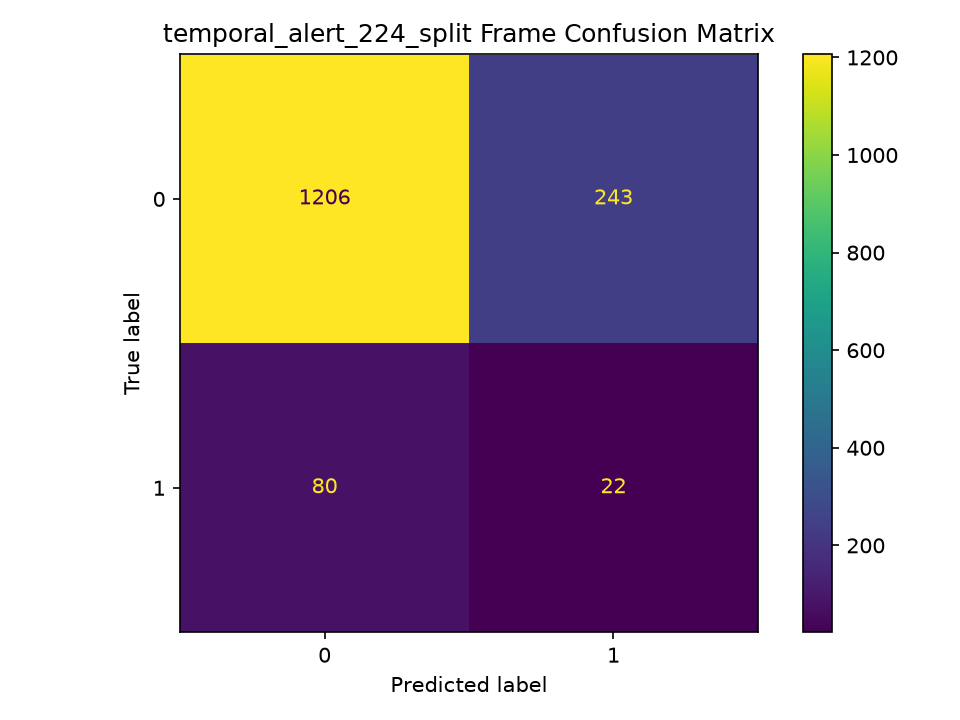

outputs\figures\temporal_alert_224_split_frame_roc_curve.png


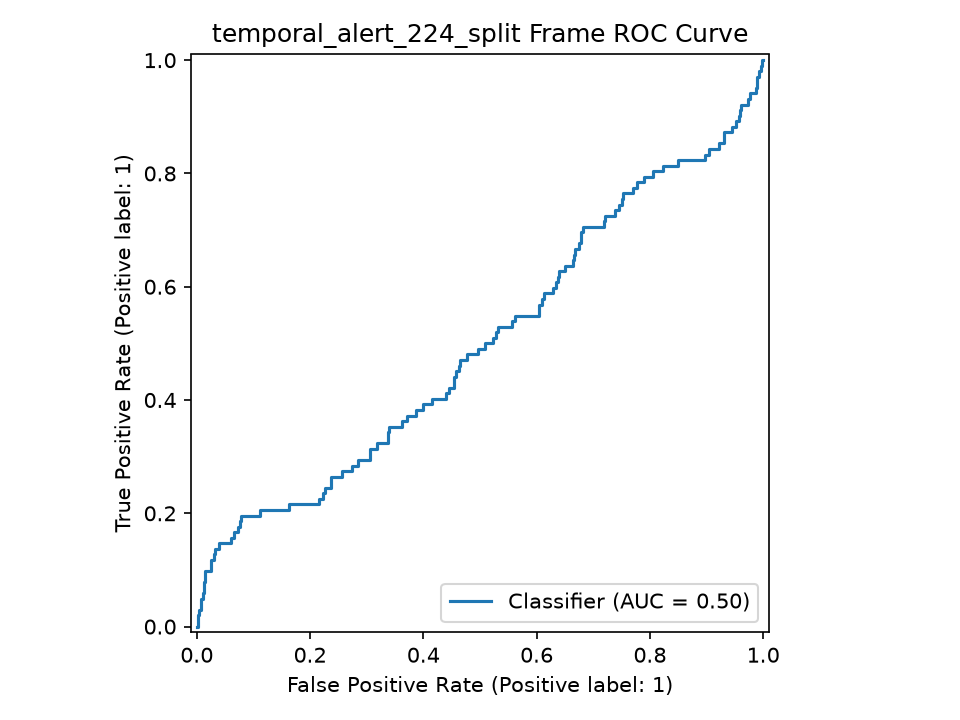

outputs\figures\temporal_alert_224_split_alert_threshold_sweep.png


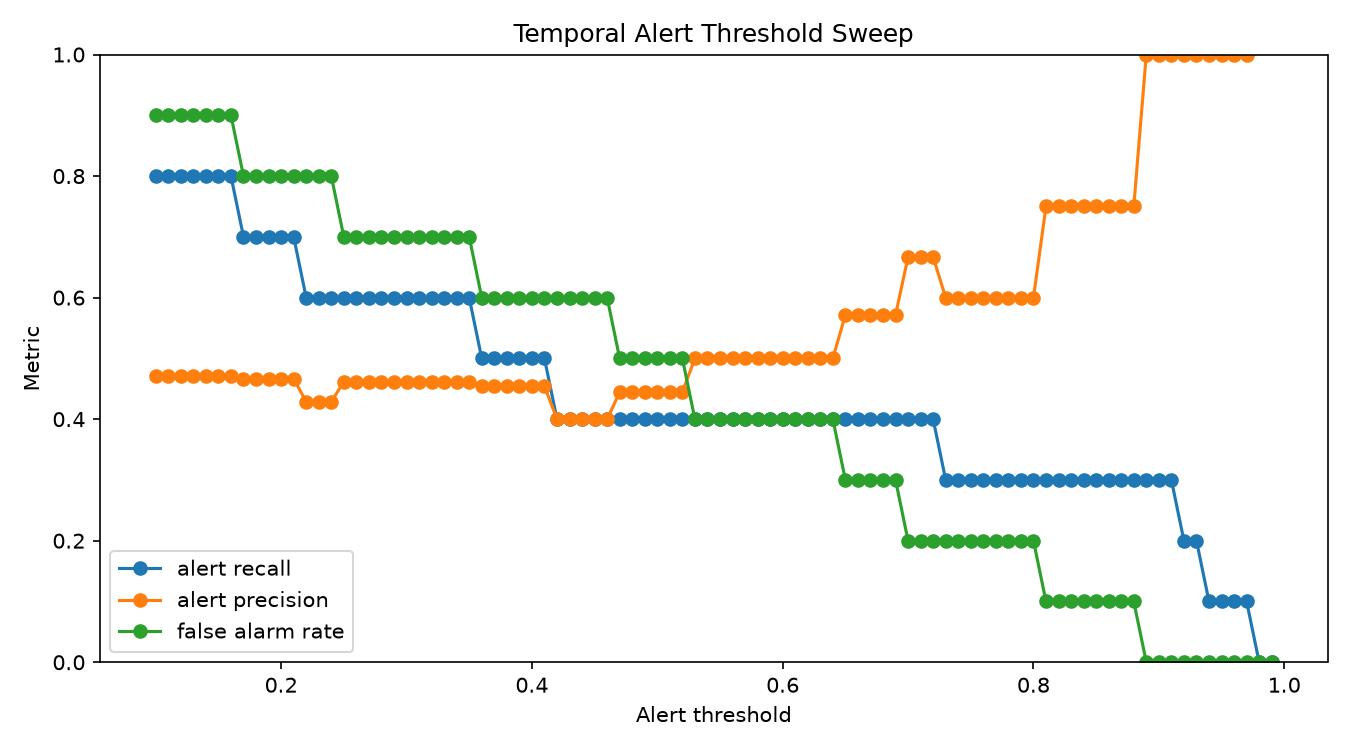

outputs\figures\temporal_alert_224_pretrained_frame_confusion_matrix.png


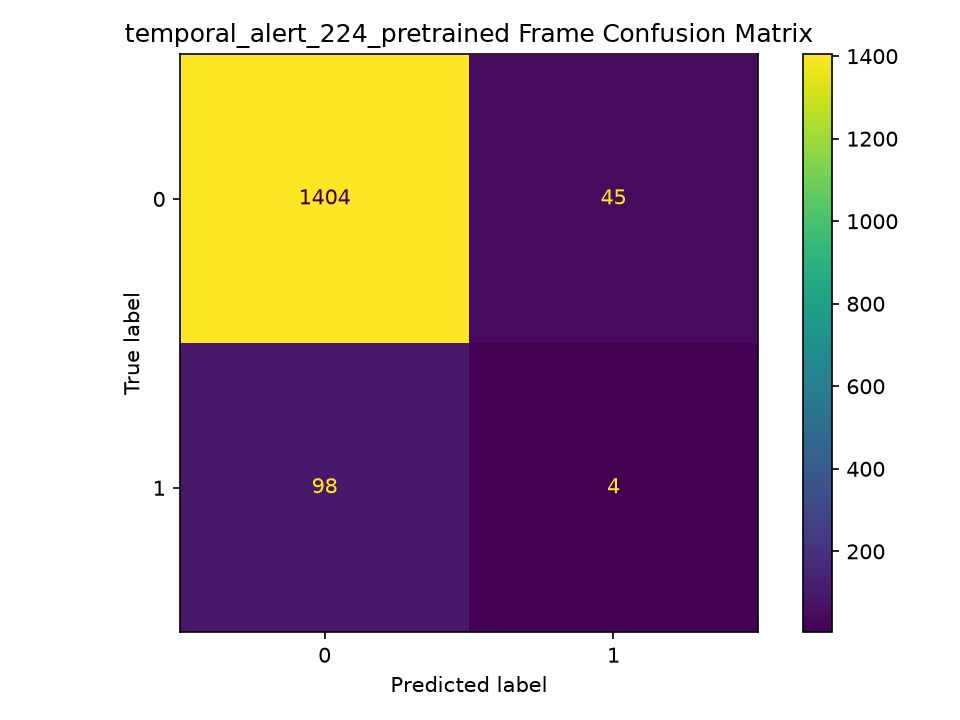

outputs\figures\temporal_alert_224_pretrained_frame_roc_curve.png


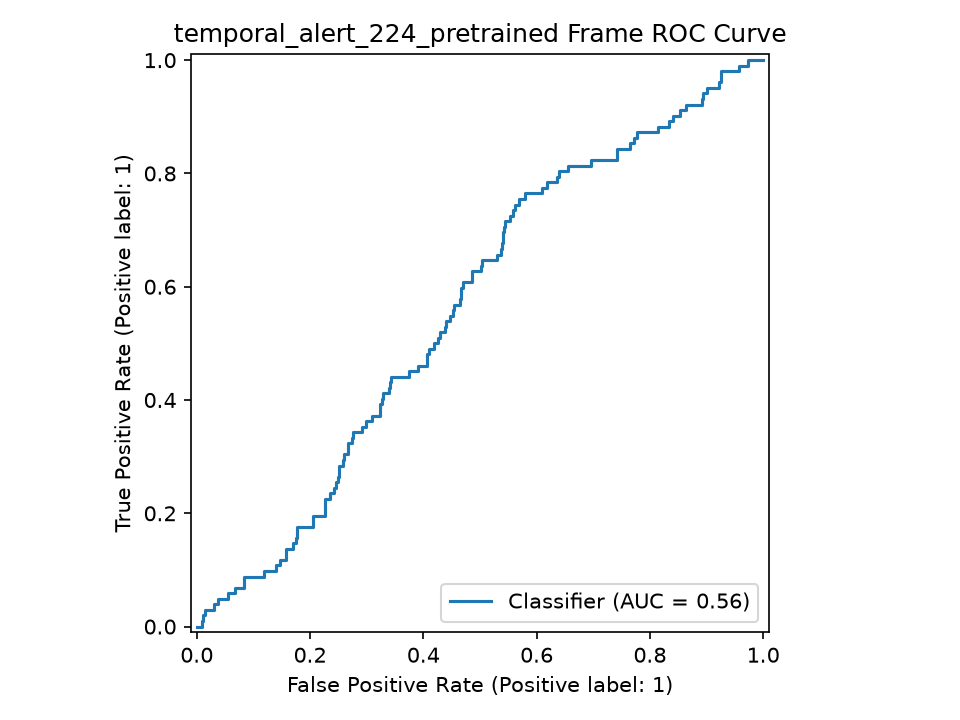

outputs\figures\temporal_alert_224_pretrained_alert_threshold_sweep.png


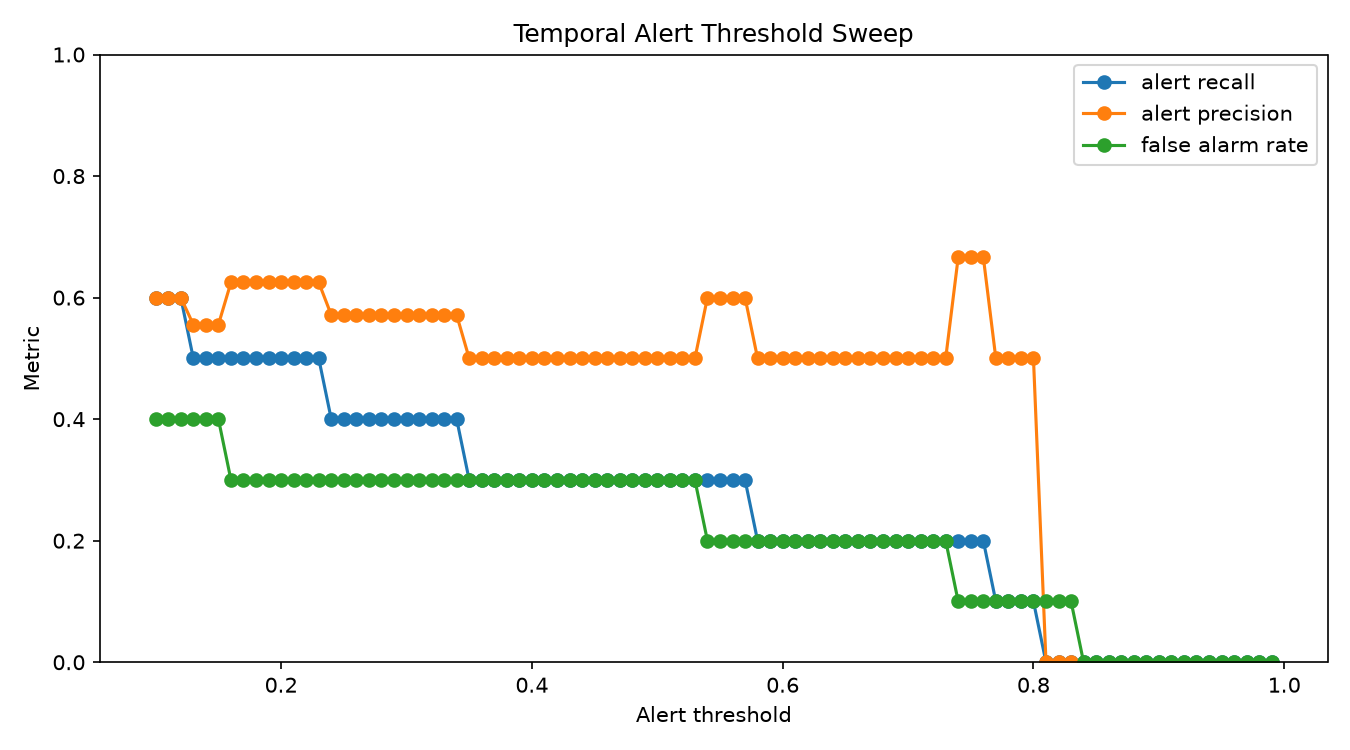

In [17]:
figure_paths = [
    FIGURES_DIR / 'temporal_alert_224_split_frame_confusion_matrix.png',
    FIGURES_DIR / 'temporal_alert_224_split_frame_roc_curve.png',
    FIGURES_DIR / 'temporal_alert_224_split_alert_threshold_sweep.png',
    FIGURES_DIR / 'temporal_alert_224_pretrained_frame_confusion_matrix.png',
    FIGURES_DIR / 'temporal_alert_224_pretrained_frame_roc_curve.png',
    FIGURES_DIR / 'temporal_alert_224_pretrained_alert_threshold_sweep.png',
]

for path in figure_paths:
    if path.exists():
        print(path.relative_to(PROJECT_ROOT))
        display(Image(filename=str(path)))
    else:
        print(f'Missing figure: {path.relative_to(PROJECT_ROOT)}')

## Interpretation for the article

Transfer learning improved calibration and false alarm control, but it did not improve event recall at the default threshold.

Most defensible statement:

> The ImageNet-pretrained ResNet18 reduced false alarms and made predicted alert timing less extreme under the corrected validation-only protocol. However, recall remained low, indicating that frame-independent classification is still insufficient for reliable early collision anticipation.

Recommended next technical step:

1. Save the best checkpoint by validation ROC-AUC or F1 instead of always keeping the final epoch.
2. Test short-window temporal aggregation.
3. Then implement a CNN + GRU/LSTM sequence model.